# 초급 프로젝트 미션

## 프로젝트 개요

첫번째 프로젝트에 오신 스프린터 여러분들을 환영합니다!

- 지금까지 학습하신 커리큘럼 초반부의 내용들을 토대로, **이미지 인식 기술을 헬스케어 분야에 접목해보는** 프로젝트를 진행해봅시다.
- 여러분들을 헬스케어 스타트업 : 헬스잇(Health Eat) 의 AI 엔지니어링 팀이라고 가정해 볼게요.
    - 헬스잇의 AI 엔지니어링 팀은 유저가 본인의 모바일 애플리케이션으로 자신이 복용중인 약 사진을 찍었을 때, 이미지 인식을 통해 해당 약에 대한 정보를 확인할 수 있는 모델을 만들어야하는 미션을 부여받았습니다.
    - 기업에서는 이를 통해 유저의 건강 상태 및 함께 복용하면 안되는 약 등 헬스케어 정보를 유저들에게 제공함으로써 비즈니스적인 가치를 만들어낼 수 있겠죠.
- 사진 속에 있는 최대 4개의 알약의 이름(클래스)과 위치(바운딩 박스)를 검출하는 모델을 구현하고, 성능을 지속적으로 개선해나가는 것이 프로젝트의 목표입니다.
    
        
- 모델 성능 검증은 코드잇 스프린트에서 별도로 세팅해둔 Kaggle에서 진행됩니다.
    - Submission 가이드라인에 따라 Output을 제출하고 Leaderbord를 통해 모델 성능을 대략적으로 확인해보세요.
    - 순위는 중요하지 않아요. 자신이 속한 팀의 점수가 지속적으로 향상되는지를 확인해보고, 향상되었다면 왜 그랬는지 트래킹하기 위한 수단으로 활용해 봅시다.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import unicodedata  # 0번 섹션에 추가 필요

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

In [4]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/") # 압축을 풀 폴더

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")

# merged_annotation json 경로
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############################################################
# 1. 병합된 JSON 파일을 읽어서 DataFrame으로 만들기
############################################################

def build_df_from_merged_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 1) 이미지 정보 매핑 (id -> file_name)
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)
        
        if file_name is None: continue
        
        img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

# 실행
df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print(f"✅ 학습 데이터 로드 완료: {len(df)} 개의 객체 탐지됨")

✅ 학습 데이터 로드 완료: 4526 개의 객체 탐지됨


In [5]:
############################################################
# 2. category_id 매핑 (겉으로는 안 바꾸고, 모델 내부에서만 사용)
############################################################

# 원본 category_id 집합
unique_cats = sorted(df["category_id"].unique())
print("고유 category_id 개수:", len(unique_cats))

# 내부용: 모델에 넣을 label (1 ~ num_classes-1), 0은 background
orig2model = {cid: i + 1 for i, cid in enumerate(unique_cats)}   # 원본 → 모델용
model2orig = {v: k for k, v in orig2model.items()}               # 모델용 → 원본

num_classes = len(unique_cats) + 1  # background 포함
print("num_classes (background 포함):", num_classes)

고유 category_id 개수: 73
num_classes (background 포함): 74


### 1. 클래스별 데이터 분포 확인 (불균형 체크)
73개의 클래스가 얼마나 균일하게 퍼져 있는지 확인해야 합니다. 특정 약물 데이터가 너무 적으면 모델이 그 약을 아예 인식하지 못할 수 있습니다.

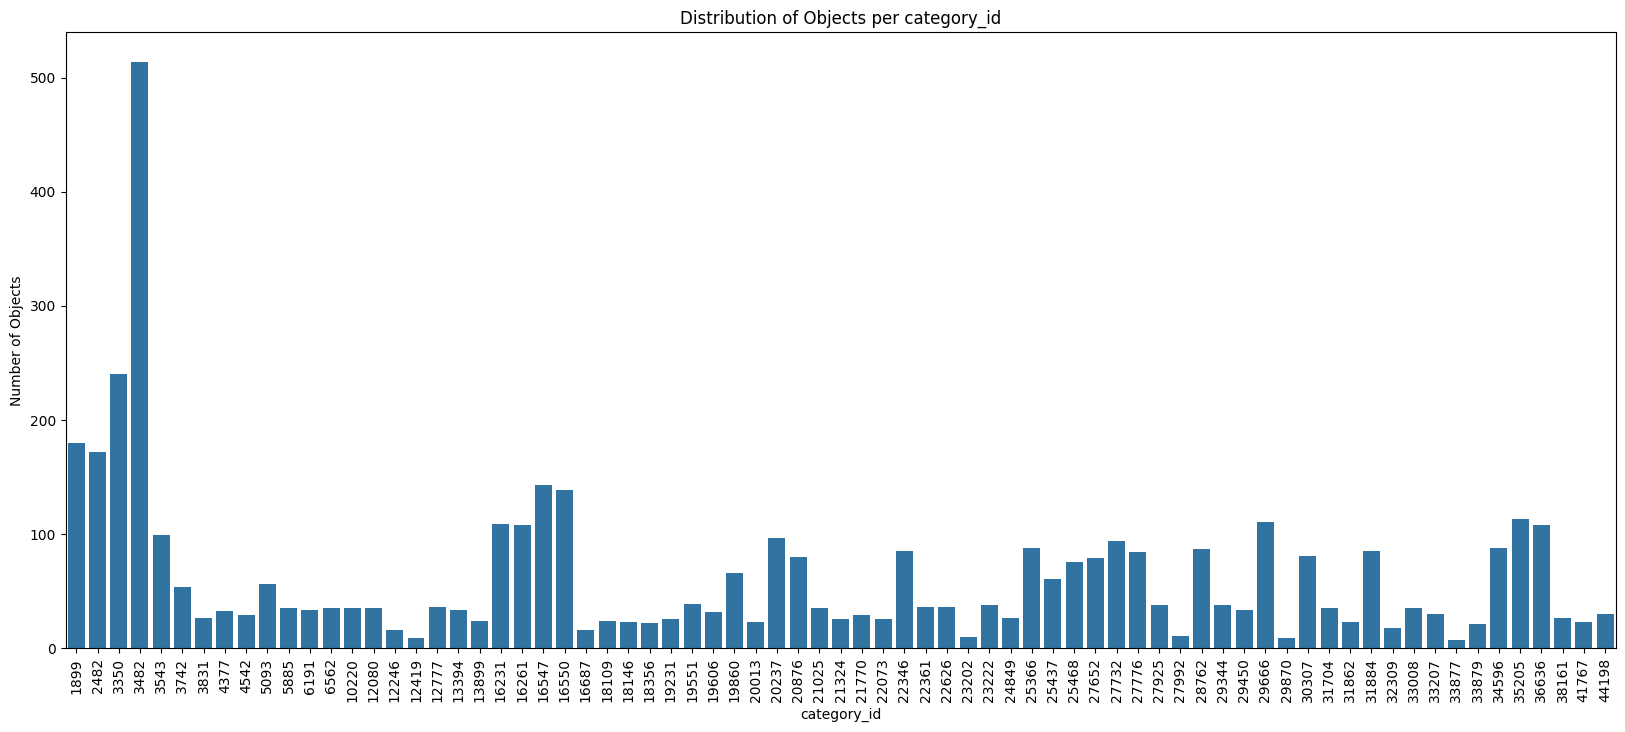

최다 객체 클래스: 3482 (514개)
최소 객체 클래스: 33877 (7개)
평균 객체 수: 62.00개


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 클래스별 객체 수 계산
class_counts = df['category_id'].value_counts().sort_index()

plt.figure(figsize=(20, 8))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Distribution of Objects per category_id")
plt.xlabel("category_id")
plt.ylabel("Number of Objects")
plt.xticks(rotation=90)
plt.show()

print(f"최다 객체 클래스: {class_counts.idxmax()} ({class_counts.max()}개)")
print(f"최소 객체 클래스: {class_counts.idxmin()} ({class_counts.min()}개)")
print(f"평균 객체 수: {class_counts.mean():.2f}개")

### 2. 이미지당 알약 개수 분포 (비즈니스 요구사항 검증)
미션이 **"최대 4개"**이므로, 현재 데이터셋에 이미지당 알약이 몇 개씩 들어있는지 확인해야 합니다.

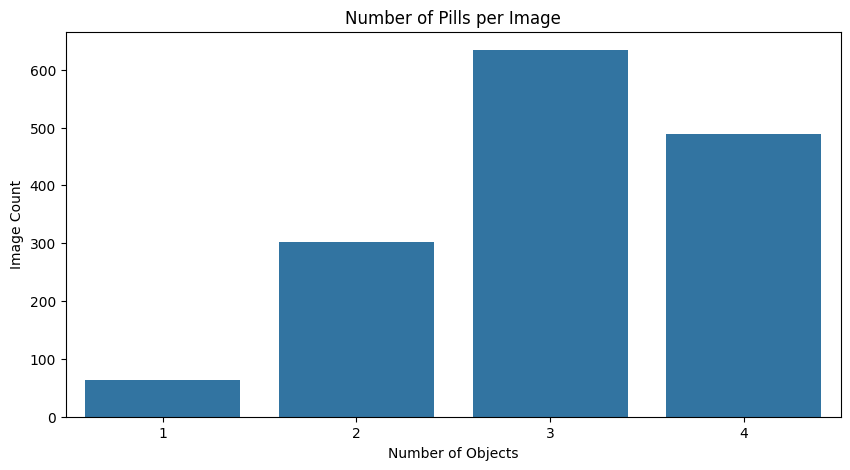

평균 알약 개수: 3.04
최대 알약 개수: 4


In [7]:
# 이미지 경로별로 그룹화하여 객체 수 카운트
objs_per_img = df.groupby('image_path').size()

plt.figure(figsize=(10, 5))
sns.countplot(x=objs_per_img.values)
plt.title("Number of Pills per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Image Count")
plt.show()

print(f"평균 알약 개수: {objs_per_img.mean():.2f}")
print(f"최대 알약 개수: {objs_per_img.max()}")

### 3. 알약 크기(Bbox Size) 분석
알약이 이미지에서 차지하는 비중이 너무 작으면(Small Object), 일반적인 모델 설정으로는 인식이 어렵습니다.

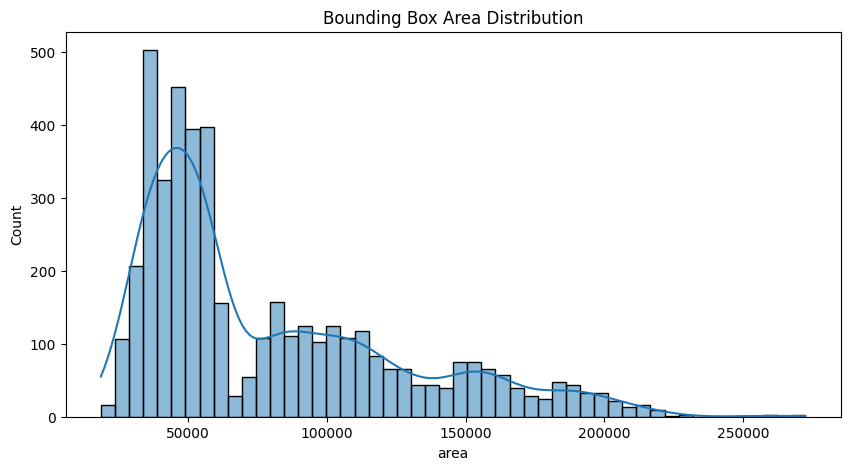

가장 작은 알약 면적: 18492.0
가장 큰 알약 면적: 272435.0


In [8]:
# 전체 이미지 대비 Bbox의 면적 비율 계산 (가정: 이미지 크기를 불러와야 정확하지만, 픽셀 단위로 우선 확인)
df['area'] = df['bbox_w'] * df['bbox_h']

plt.figure(figsize=(10, 5))
sns.histplot(df['area'], bins=50, kde=True)
plt.title("Bounding Box Area Distribution")
plt.show()

print(f"가장 작은 알약 면적: {df['area'].min()}")
print(f"가장 큰 알약 면적: {df['area'].max()}")

### 4. 실제 이미지와 바운딩 박스 시각화 (QA)
데이터가 정상적으로 로드되었는지 눈으로 확인하는 것이 가장 중요합니다. 랜덤하게 이미지를 뽑아 박스를 그려봅니다.

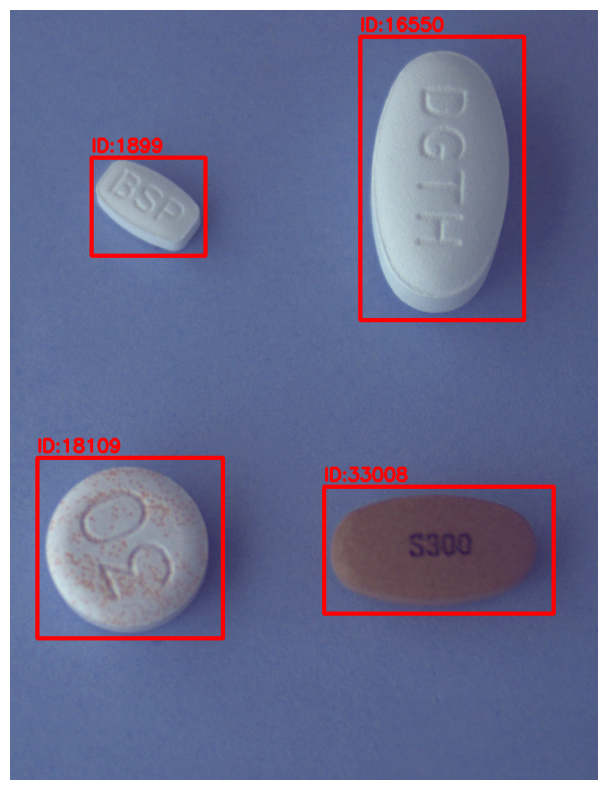

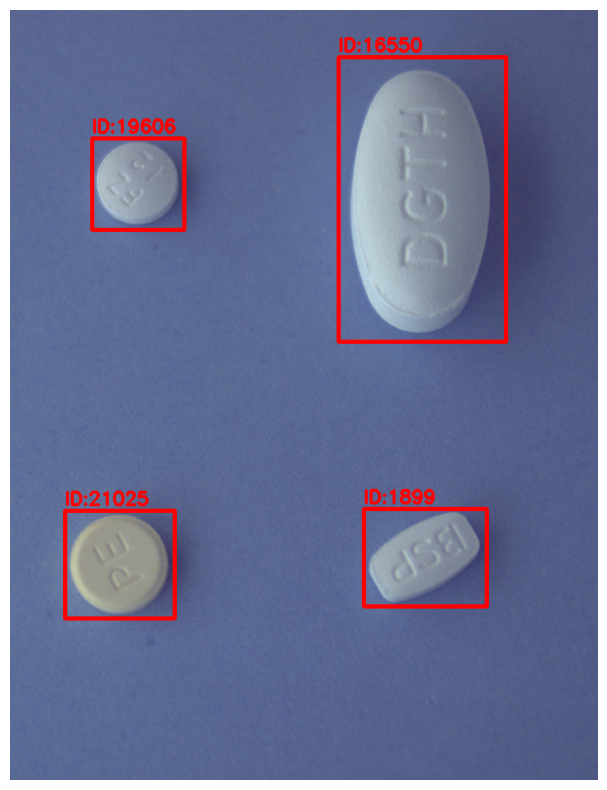

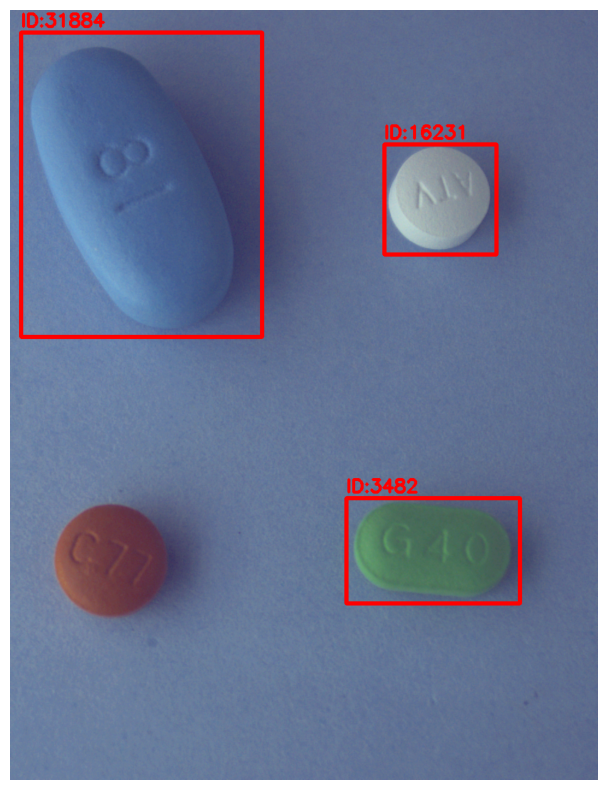

In [9]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def draw_random_sample(df, num_samples=3):
    sample_paths = df['image_path'].unique()
    np.random.seed(42)
    selected_paths = np.random.choice(sample_paths, num_samples)

    for path in selected_paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 해당 이미지의 모든 객체 정보 가져오기
        annots = df[df['image_path'] == path]
        
        for _, row in annots.iterrows():
            x, y, w, h = int(row['bbox_x']), int(row['bbox_y']), int(row['bbox_w']), int(row['bbox_h'])
            label = row['category_id']
            # 박스 그리기
            cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 5)
            cv2.putText(img, f"ID:{label}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)

        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

draw_random_sample(df)